In [3]:
from typing import List, Tuple, Dict, Any
import h5py

In [4]:
data_path: str = '/mnt/d/Downloads/Senior_Thesis/INSTANCE/Instance_sample_dataset_v3/data/Instance_events_gm_10k.hdf5'
f = h5py.File(data_path, "r")

f_keys = list(f.keys())

In [5]:
def print_structure(name, obj):
    print(name)

f.visititems(print_structure)

data
data/11030611.IV.OFFI..HH
data/11030611.IV.PIEI..HH
data/11030611.IV.PIEI..HN
data/11030611.IV.RM33..EH
data/11030611.IV.RM33..HN
data/11030611.IV.SEF1..HN
data/11030611.IV.SNTG..HH
data/11030611.IV.SNTG..HN
data/11030611.IV.SSFR..HH
data/11030611.IV.SSFR..HN
data/11030611.IV.SSM1..HN
data/11030611.IV.T0110..HH
data/11030611.IV.T1201..HN
data/11030611.IV.T1202..EH
data/11030611.IV.T1204..EH
data/11030611.IV.T1211..EH
data/11030611.IV.T1211..HN
data/11030611.IV.T1212..EH
data/11030611.IV.T1212..HN
data/11030611.IV.T1213..EH
data/11030611.IV.T1213..HN
data/11030611.IV.T1215..EH
data/11030611.IV.T1215..HN
data/11030611.IV.T1216..EH
data/11030611.IV.T1216..HN
data/11030611.IV.T1217..EH
data/11030611.IV.T1217..HN
data/11030611.IV.T1218..EH
data/11030611.IV.T1218..HN
data/11030611.IV.T1219..EH
data/11030611.IV.T1219..HN
data/11030611.IV.T1220..EH
data/11030611.IV.T1220..HN
data/11030611.IV.T1221..EH
data/11030611.IV.T1221..HN
data/11030611.IV.T1241..EH
data/11030611.IV.T1241..HN
data/11

In [9]:
waveforms = f[f_keys[0]]

print([d for d in dir(waveforms)])

['_MutableMapping__marker', '__abstractmethods__', '__bool__', '__class__', '__class_getitem__', '__contains__', '__delattr__', '__delitem__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getitem__', '__getnewargs__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__iter__', '__le__', '__len__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__reversed__', '__setattr__', '__setitem__', '__sizeof__', '__slots__', '__str__', '__subclasshook__', '__weakref__', '_abc_impl', '_d', '_e', '_get', '_id', '_ipython_key_completions_', '_lapl', '_lcpl', 'attrs', 'build_virtual_dataset', 'clear', 'copy', 'create_dataset', 'create_dataset_like', 'create_group', 'create_virtual_dataset', 'file', 'get', 'id', 'items', 'keys', 'move', 'name', 'parent', 'pop', 'popitem', 'ref', 'regionref', 'require_dataset', 'require_group', 'setdefault', 'update', 'values', 'visit', 'visit_links', 'visitit

In [16]:
for val in waveforms.values():
    print(val[0].shape)
    break

(12000,)


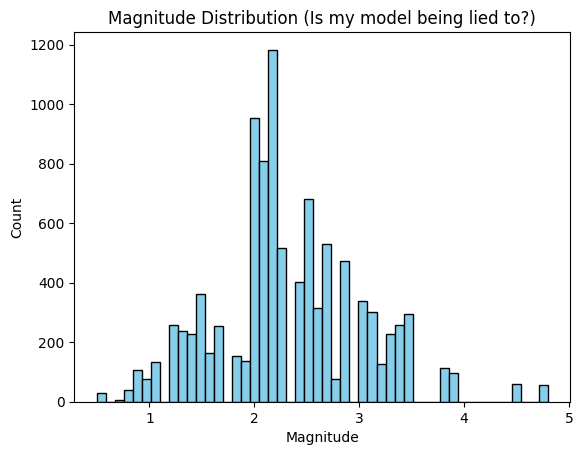

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

csv_path: str = "/mnt/d/Downloads/Senior_Thesis/INSTANCE/Instance_sample_dataset_v3/metadata/metadata_Instance_events_10k.csv"
df = pd.read_csv(csv_path)
plt.hist(df['source_magnitude'], bins=50, color='skyblue', edgecolor='black')
plt.title("Magnitude Distribution (Is my model being lied to?)")
plt.xlabel("Magnitude")
plt.ylabel("Count")
plt.show()


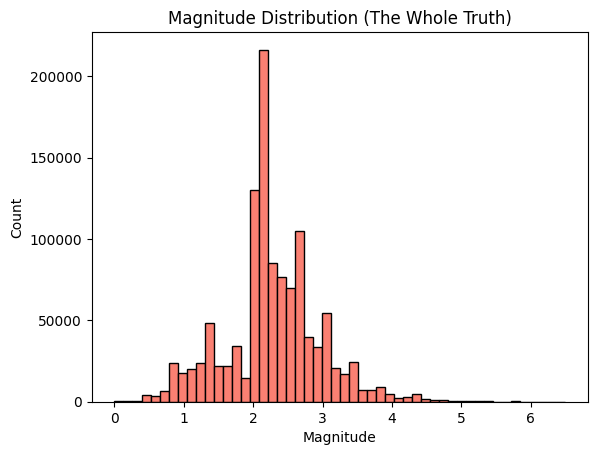

In [2]:
import matplotlib.pyplot as plt
import pandas as pd

csv_path = "/mnt/d/Downloads/Senior_Thesis/INSTANCE/metadata_Instance_events_v3.csv.bz2"

df = pd.read_csv(csv_path, compression='bz2', usecols=['source_magnitude'])

plt.hist(df['source_magnitude'].dropna(), bins=50, color='salmon', edgecolor='black')

plt.title("Magnitude Distribution (The Whole Truth)")
plt.xlabel("Magnitude")
plt.ylabel("Count")
plt.show()

In [3]:
import pandas as pd

# Assuming you already loaded your df. 
# (Drop the `usecols` from before if you actually need the other columns to fetch the waveforms later)

# 1. Grab M1.0 to 2.99 and pick 5k
low_mag = df[(df['source_magnitude'] >= 1.0) & (df['source_magnitude'] < 3.0)]
low_sampled = low_mag.sample(n=5000, random_state=42)

# 2. Grab M3.0 to 4.99 and pick 5k
mid_mag = df[(df['source_magnitude'] >= 3.0) & (df['source_magnitude'] < 5.0)]
mid_sampled = mid_mag.sample(n=5000, random_state=42)

# 3. Hoard every single M5.0+
high_mag = df[df['source_magnitude'] >= 5.0]

# Mash them all together
balanced_df = pd.concat([low_sampled, mid_sampled, high_mag])

# CRITICAL: Shuffle the dataframe. 
# If you don't do this, your model sees 5k lows, then 5k mids, then highs, and will get totally confused.
balanced_df = balanced_df.sample(frac=1, random_state=42).reset_index(drop=True)

# Sanity check
print("Dataset size:", len(balanced_df))
print(balanced_df['source_magnitude'].describe())

Dataset size: 11757
count    11757.000000
mean         3.169559
std          1.189299
min          1.000000
25%          2.300000
50%          3.000000
75%          3.600000
max          6.500000
Name: source_magnitude, dtype: float64


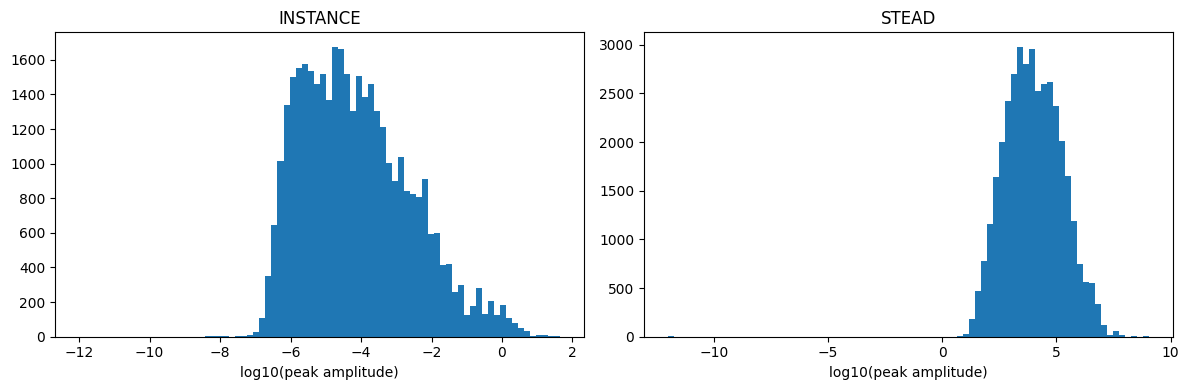

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

events = np.memmap("/home/aidar/study/senior_thesis/data/unified/waveforms_events.bin", dtype="float32", mode="r")
meta   = pd.read_csv("/home/aidar/study/senior_thesis/data/unified/metadata_events.csv")

events = events.reshape(-1, 3, 1000)

inst_idx  = meta[meta["source"] == "instance"].index.to_numpy()
stead_idx = meta[meta["source"].str.startswith("stead")].index.to_numpy()

inst_peaks  = np.abs(events[inst_idx,  0, :]).max(axis=1)
stead_peaks = np.abs(events[stead_idx, 0, :]).max(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, peaks, label in zip(axes, [inst_peaks, stead_peaks], ["INSTANCE", "STEAD"]):
    ax.hist(np.log10(peaks + 1e-12), bins=80)
    ax.set_xlabel("log10(peak amplitude)")
    ax.set_title(label)
plt.tight_layout()
plt.show()


100%|██████████| 101272/101272 [00:06<00:00, 15737.88it/s]



INSTANCE:
  count: 101272
  min  : 1.47e-11
  max  : 4.29e+02
  mean : 1.51e-02
  median : 5.25e-06
  std  : 1.6695408821105957


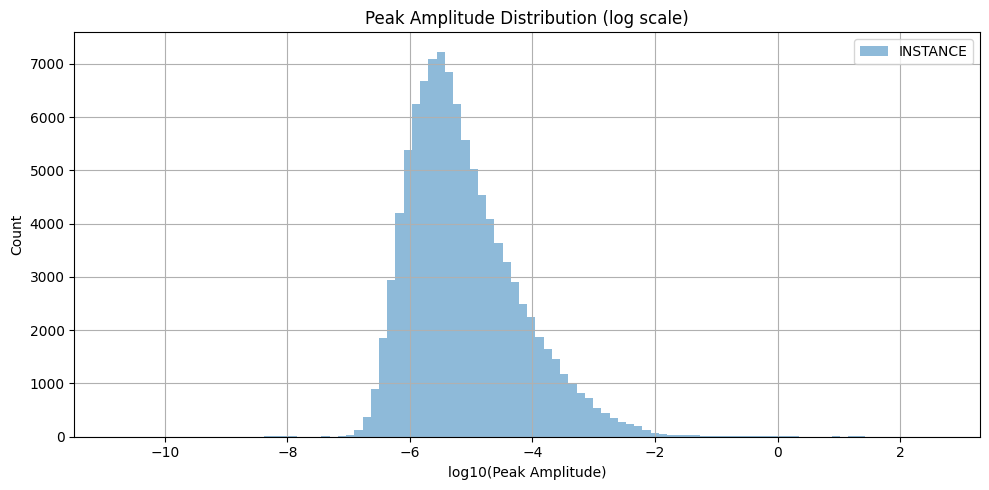

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm


MEMMAP_PATH = "/home/aidar/study/senior_thesis/data/INSTANCE/unprocessed_amplitude/waveforms_events.bin"
CSV_PATH    = "/home/aidar/study/senior_thesis/data/INSTANCE/unprocessed_amplitude/metadata_events.csv"
N_SAMPLES   = 101272   # adjust to your dataset
is_log: bool = True


waveforms = np.memmap(
    MEMMAP_PATH, dtype="float32", mode="r",
    shape=(N_SAMPLES, 3, 1000)
)

metadata = pd.read_csv(CSV_PATH)


peaks = []
sources = []

for i in tqdm(range(len(metadata))):
    clip = waveforms[i]
    peak = np.abs(clip).max()
    peaks.append(peak)
    sources.append(metadata.iloc[i]["source"])

peaks = np.array(peaks)
sources = np.array(sources)

# split
instance_peaks = peaks[sources == "instance"]
# stead_peaks    = peaks[sources != "instance"]


def stats(name, arr):
    print(f"\n{name}:")
    print(f"  count: {len(arr)}")
    print(f"  min  : {arr.min():.2e}")
    print(f"  max  : {arr.max():.2e}")
    print(f"  mean : {arr.mean():.2e}")
    print(f"  median : {np.quantile(arr, 0.5):.2e}")
    print(f"  std  : {arr.std()}")

stats("INSTANCE", instance_peaks)
# stats("STEAD", stead_peaks)

log_instance = np.log10(instance_peaks + 1e-12) if is_log else instance_peaks
# log_stead    = np.log10(stead_peaks + 1e-12)


plt.figure(figsize=(10, 5))

plt.hist(log_instance, bins=100, alpha=0.5, label="INSTANCE")
# plt.hist(log_stead, bins=100, alpha=0.5, label="STEAD")

plt.xlabel("log10(Peak Amplitude)" if is_log else "(Peak Amplitude)")
plt.ylabel("Count")
plt.title("Peak Amplitude Distribution (log scale)" if is_log else "Peak Amplitude Distribution")
plt.legend()
plt.grid()

plt.tight_layout()
# plt.savefig("amplitude_distribution.png", dpi=200)
plt.show()

# plt.figure(figsize=(6, 5))
# plt.boxplot([log_instance, log_stead], tick_labels=["INSTANCE", "STEAD"])
# plt.ylabel("log10(Peak Amplitude)")
# plt.title("Amplitude Comparison")

# plt.tight_layout()
# plt.savefig("amplitude_boxplot.png", dpi=200)
# plt.close()


# mean_diff = log_instance.mean() - log_stead.mean()
# print(f"\nMean log-amplitude difference (INSTANCE - STEAD): {mean_diff:.3f}")


magnitudes = metadata["source_magnitude"].values

valid_mask = peaks > 0
# corr = np.corrcoef(np.log(peaks[valid_mask]), magnitudes[valid_mask])[0, 1]

# print(f"\nCorrelation (log peak vs magnitude): {corr:.3f}")

In [4]:
"""
Amplitude distribution comparison — all raw sample values:
  - 10k INSTANCE sample  (from HDF5, sliced at P arrival + zero-pad)
  - ~100k unified dataset (from memmap .bin)

Per-channel (E, N, Z). Histograms built incrementally to keep RAM sane.
"""

import json
import os
import numpy as np
import pandas as pd
import h5py
import matplotlib.pyplot as plt
from tqdm import tqdm

# ─────────────────────────────────────────────
#  CONFIGURE PATHS
# ─────────────────────────────────────────────

SAMPLE_CSV   = "/mnt/d/Downloads/Senior_Thesis/INSTANCE/Instance_sample_dataset_v3/metadata/metadata_Instance_events_10k.csv"
SAMPLE_HDF5  = "/mnt/d/Downloads/Senior_Thesis/INSTANCE/Instance_sample_dataset_v3/data/Instance_events_counts_10k.hdf5"
TARGET_LEN   = 1000
PAD_LEN      = 0
TOTAL        = TARGET_LEN + PAD_LEN  # 1000

MEMMAP_PATH  = "/home/aidar/study/senior_thesis/data/INSTANCE/normalized_amplitude/waveforms_events.bin"
INFO_PATH    = "/home/aidar/study/senior_thesis/data/INSTANCE/normalized_amplitude/info.json"

OUT_DIR      = "."
CHANNEL_NAMES = ["E", "N", "Z"]

# Histogram bin edges — tune if your data range is different
# Will be computed from a data sample first, then reused for consistency
N_BINS       = 200
CHUNK_SIZE   = 2000  # waveforms per chunk for memmap iteration

# ─────────────────────────────────────────────
#  INCREMENTAL HISTOGRAM BUILDER
# ─────────────────────────────────────────────

class IncrementalHistogram:
    """Accumulates histogram counts without storing all values in memory."""

    def __init__(self, bin_edges: np.ndarray) -> None:
        self.bin_edges = bin_edges                          # (N_BINS+1,)
        self.counts    = np.zeros(len(bin_edges) - 1, dtype=np.int64)

    def update(self, values: np.ndarray) -> None:
        """values: 1D array of raw sample values."""
        c, _ = np.histogram(values, bins=self.bin_edges)
        self.counts += c


def estimate_bin_edges(sample_values: np.ndarray, n_bins: int = N_BINS) -> np.ndarray:
    """
    Use a representative sample to compute shared bin edges.
    Clips at 1st and 99th percentile to avoid extreme outliers dominating the range.
    """
    lo = np.percentile(sample_values, 1)
    hi = np.percentile(sample_values, 99)
    return np.linspace(lo, hi, n_bins + 1)


# ─────────────────────────────────────────────
#  10k SAMPLE LOADER
# ─────────────────────────────────────────────

def collect_10k_samples(n_probe: int = 500) -> tuple[np.ndarray, list[np.ndarray]]:
    """
    Pass 1 — collect a flat probe sample (for bin edge estimation).
    Pass 2 — build per-channel incremental histograms.

    Returns (probe_flat, list_of_all_values_per_channel).
    For 10k waveforms the full arrays fit in RAM, so we just store them.
    """
    print("\nLoading 10k INSTANCE sample from HDF5...")

    df = pd.read_csv(SAMPLE_CSV)
    df = df.dropna(subset=["source_magnitude"])
    df = df[df["trace_eval_P"] == "manual"]
    df = df[df["station_channels"].isin(["EH", "HH"])]
    df = df[(df["trace_npts"] - df["trace_P_arrival_sample"]) >= TOTAL]
    df = df.reset_index(drop=True)

    # (N_valid, 3, 1000) — 10k fits fine in RAM (~120 MB float32)
    clips = []
    with h5py.File(SAMPLE_HDF5, "r") as h5:
        for _, row in tqdm(df.iterrows(), total=len(df), desc="  reading HDF5"):
            p_idx = int(row["trace_P_arrival_sample"])
            try:
                w    = h5["data"][row["trace_name"]][:]
                clip = w[:, p_idx : p_idx + TARGET_LEN]
                clip = np.pad(clip, ((0, 0), (0, PAD_LEN)), mode="constant")
                clips.append(clip)
            except KeyError:
                continue

    arr = np.array(clips, dtype=np.float32)  # (N, 3, 1000)
    print(f"  Loaded {len(arr):,} traces.")

    probe = arr[:n_probe].reshape(-1)        # flat probe for bin-edge estimation

    # Per-channel flat arrays
    per_channel = [arr[:, ch, :].reshape(-1) for ch in range(3)]

    return probe, per_channel


# ─────────────────────────────────────────────
#  UNIFIED MEMMAP LOADER (incremental)
# ─────────────────────────────────────────────

def build_unified_histograms(
    bin_edges_per_channel: list[np.ndarray],
) -> list[IncrementalHistogram]:
    """
    Streams through the memmap in chunks and accumulates histograms per channel.
    Never loads the full dataset into RAM.
    """
    print("\nBuilding histograms for unified ~100k dataset from memmap...")

    with open(INFO_PATH) as f:
        info = json.load(f)
    n, _, t = info["events"]["shape"]

    waveforms = np.memmap(MEMMAP_PATH, dtype="float32", mode="r", shape=(n, 3, t))
    hists     = [IncrementalHistogram(edges) for edges in bin_edges_per_channel]

    for start in tqdm(range(0, n, CHUNK_SIZE), desc="  chunking memmap"):
        chunk = np.array(waveforms[start : start + CHUNK_SIZE])  # (chunk, 3, T) — copy to RAM
        for ch in range(3):
            hists[ch].update(chunk[:, ch, :].reshape(-1))

    del waveforms
    return hists


# ─────────────────────────────────────────────
#  STATS PRINTER
# ─────────────────────────────────────────────

def print_stats_from_arrays(per_channel: list[np.ndarray], label: str) -> None:
    print(f"\n{'─'*60}")
    print(f"  {label}")
    print(f"{'─'*60}")
    header = f"  {'Ch':<5} {'Mean':>10} {'Std':>10} {'Min':>12} {'Q1':>12} {'Median':>12} {'Q3':>12} {'Q99':>12} {'Max':>12}"
    print(header)
    for ch, name in enumerate(CHANNEL_NAMES):
        v = per_channel[ch]
        print(
            f"  {name:<5} "
            f"{v.mean():>10.2f} "
            f"{v.std():>10.2f} "
            f"{v.min():>12.2f} "
            f"{np.percentile(v, 25):>12.2f} "
            f"{np.median(v):>12.2f} "
            f"{np.percentile(v, 75):>12.2f} "
            f"{np.percentile(v, 99):>12.2f} "
            f"{v.max():>12.2f}"
        )


def print_stats_from_hists(hists: list[IncrementalHistogram], label: str) -> None:
    """Approximate stats from histogram bin midpoints (no full array available)."""
    print(f"\n{'─'*60}")
    print(f"  {label}  (approx. from histogram)")
    print(f"{'─'*60}")
    header = f"  {'Ch':<5} {'Mean':>10} {'Q1':>12} {'Median':>12} {'Q3':>12} {'Q99':>12}"
    print(header)
    for ch, name in enumerate(CHANNEL_NAMES):
        hist   = hists[ch]
        mids   = 0.5 * (hist.bin_edges[:-1] + hist.bin_edges[1:])
        counts = hist.counts.astype(np.float64)
        total  = counts.sum()
        mean   = (mids * counts).sum() / total

        # Approximate quantiles via cumulative sum
        cdf    = np.cumsum(counts) / total
        def quantile(q):
            idx = np.searchsorted(cdf, q)
            return mids[min(idx, len(mids) - 1)]

        print(
            f"  {name:<5} "
            f"{mean:>10.2f} "
            f"{quantile(0.25):>12.2f} "
            f"{quantile(0.50):>12.2f} "
            f"{quantile(0.75):>12.2f} "
            f"{quantile(0.99):>12.2f} "
        )


# ─────────────────────────────────────────────
#  PLOTTING
# ─────────────────────────────────────────────

def plot_distributions(
    per_channel_10k:     list[np.ndarray],
    hists_unified:       list[IncrementalHistogram],
    bin_edges_per_ch:    list[np.ndarray],
) -> None:

    fig, axes = plt.subplots(2, 3, figsize=(16, 9), dpi=200)
    fig.suptitle("Raw Sample Value Distribution per Channel", fontsize=14)

    row_configs = [
        (per_channel_10k,  "10k INSTANCE sample",  (0.0, 0.35, 0.85), "array"),
        (hists_unified,    "~100k unified dataset", (0.7, 0.1,  0.1),  "hist"),
    ]

    for row_idx, (data, title, color, mode) in enumerate(row_configs):
        for col_idx, ch_name in enumerate(CHANNEL_NAMES):
            ax = axes[row_idx][col_idx]

            if mode == "array":
                v       = data[col_idx]
                edges   = bin_edges_per_ch[col_idx]
                counts, _ = np.histogram(v, bins=edges)
                median_v  = np.median(v)
                mean_v    = v.mean()
            else:
                hist    = data[col_idx]
                edges   = hist.bin_edges
                counts  = hist.counts
                mids    = 0.5 * (edges[:-1] + edges[1:])
                total   = counts.astype(np.float64).sum()
                cdf     = np.cumsum(counts) / total
                median_v = mids[np.searchsorted(cdf, 0.50)]
                mean_v   = (mids * counts).sum() / total

            bin_width = edges[1] - edges[0]
            ax.bar(
                edges[:-1], counts, width=bin_width,
                align="edge", color=color, alpha=0.85, linewidth=0,
            )
            ax.axvline(median_v, color="orange", linestyle="--", linewidth=1.3, label=f"Median={median_v:.1f}")
            ax.axvline(mean_v,   color="lime",   linestyle="-",  linewidth=1.3, label=f"Mean={mean_v:.1f}")

            ax.set_title(f"{title} — Ch {ch_name}")
            ax.set_xlabel("Sample Value")
            ax.set_ylabel("Count")
            ax.legend(fontsize=8)
            ax.ticklabel_format(style="sci", axis="both", scilimits=(0, 0))

    plt.tight_layout()
    out_path = os.path.join(OUT_DIR, "amplitude_distributions.jpg")
    plt.savefig(out_path, bbox_inches="tight")
    plt.close(fig)
    print(f"\nFigure saved to `{out_path}`")


# ─────────────────────────────────────────────
#  MAIN
# ─────────────────────────────────────────────

if __name__ == "__main__":

    # ── 1. Load 10k (fits in RAM) ─────────────────────────────────────────
    probe_10k, per_channel_10k = collect_10k_samples()

    # ── 2. Estimate bin edges from 10k probe (shared across both datasets) ─
    #       One set of edges per channel so histograms are directly comparable
    bin_edges_per_ch = [
        estimate_bin_edges(per_channel_10k[ch]) for ch in range(3)
    ]

    # ── 3. Stats for 10k (exact, from full arrays) ────────────────────────
    print_stats_from_arrays(per_channel_10k, "10k INSTANCE sample — raw sample values")

    # ── 4. Stream through memmap, build incremental histograms ───────────
    hists_unified = build_unified_histograms(bin_edges_per_ch)

    # ── 5. Approximate stats for unified (from histogram midpoints) ───────
    print_stats_from_hists(hists_unified, "~100k unified dataset — raw sample values")

    # ── 6. Plot ───────────────────────────────────────────────────────────
    plot_distributions(per_channel_10k, hists_unified, bin_edges_per_ch)


Loading 10k INSTANCE sample from HDF5...


  reading HDF5: 100%|██████████| 6410/6410 [00:06<00:00, 1038.51it/s]


  Loaded 6,410 traces.

────────────────────────────────────────────────────────────
  10k INSTANCE sample — raw sample values
────────────────────────────────────────────────────────────
  Ch          Mean        Std          Min           Q1       Median           Q3          Q99          Max
  E        -191.98   28013.42  -4341162.00      -275.00         0.00       274.00     26303.00   2979269.00
  N         -78.57   24572.49  -6028056.00      -280.00         0.00       280.00     27265.00   5653510.00
  Z        -504.48   45222.22  -6799248.00      -218.00         0.00       219.00     17144.00   3956798.00

Building histograms for unified ~100k dataset from memmap...


  chunking memmap: 100%|██████████| 51/51 [00:01<00:00, 39.81it/s]



────────────────────────────────────────────────────────────
  ~100k unified dataset — raw sample values  (approx. from histogram)
────────────────────────────────────────────────────────────
  Ch          Mean           Q1       Median           Q3          Q99
  E         -67.99       -67.99       -67.99       -67.99       -67.99 
  N        -125.27      -125.27      -125.27      -125.27      -125.27 
  Z          19.05        19.05        19.05        19.05        19.05 

Figure saved to `./amplitude_distributions.jpg`


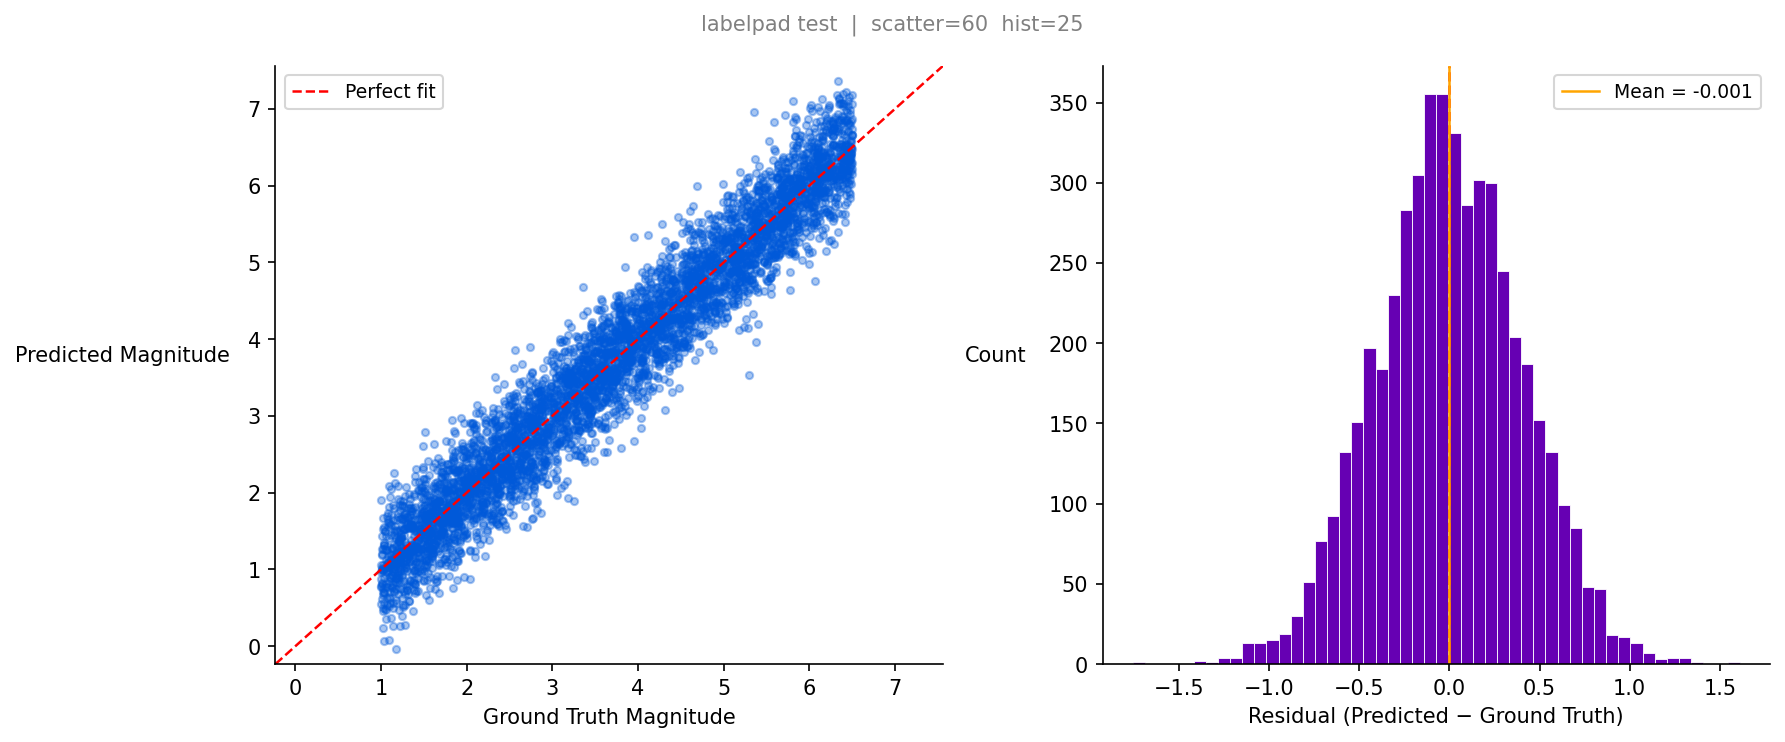

Saved to labelpad_test.jpg


In [5]:
import numpy as np
import matplotlib.pyplot as plt

# --- tweak these ---
SCATTER_LABELPAD = 60
HIST_LABELPAD    = 25
# -------------------

rng = np.random.default_rng(42)
targets = rng.uniform(1, 6.5, 5000)
preds   = targets + rng.normal(0, 0.4, 5000)
residuals = preds - targets

fig, axes = plt.subplots(1, 2, figsize=(12, 5), dpi=150)

# --- scatter ---
mag_min = min(targets.min(), preds.min()) - 0.2
mag_max = max(targets.max(), preds.max()) + 0.2
axes[0].scatter(targets, preds, alpha=0.35, s=12, color=(0, 0.35, 0.85))
axes[0].plot([mag_min, mag_max], [mag_min, mag_max], 'r--', linewidth=1.2, label='Perfect fit')
axes[0].set_xlim(mag_min, mag_max)
axes[0].set_ylim(mag_min, mag_max)
axes[0].set_xlabel('Ground Truth Magnitude')
axes[0].set_ylabel('Predicted Magnitude', rotation='horizontal', labelpad=SCATTER_LABELPAD)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)
axes[0].legend(fontsize=9)

# --- histogram ---
axes[1].hist(residuals, bins=50, color=(0.4, 0.0, 0.7), edgecolor='white', linewidth=0.4)
axes[1].axvline(0, color='red', linestyle='--', linewidth=1.2)
axes[1].axvline(np.mean(residuals), color='orange', linestyle='-', linewidth=1.2,
                label=f'Mean = {np.mean(residuals):.3f}')
axes[1].set_xlabel('Residual (Predicted − Ground Truth)')
axes[1].set_ylabel('Count', rotation='horizontal', labelpad=HIST_LABELPAD)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
axes[1].legend(fontsize=9)

# print current values on the figure so you know what you're looking at
fig.suptitle(f'labelpad test  |  scatter={SCATTER_LABELPAD}  hist={HIST_LABELPAD}', fontsize=10, color='grey')

plt.tight_layout()
plt.savefig('labelpad_test.jpg', bbox_inches='tight')
plt.show()
print('Saved to labelpad_test.jpg')

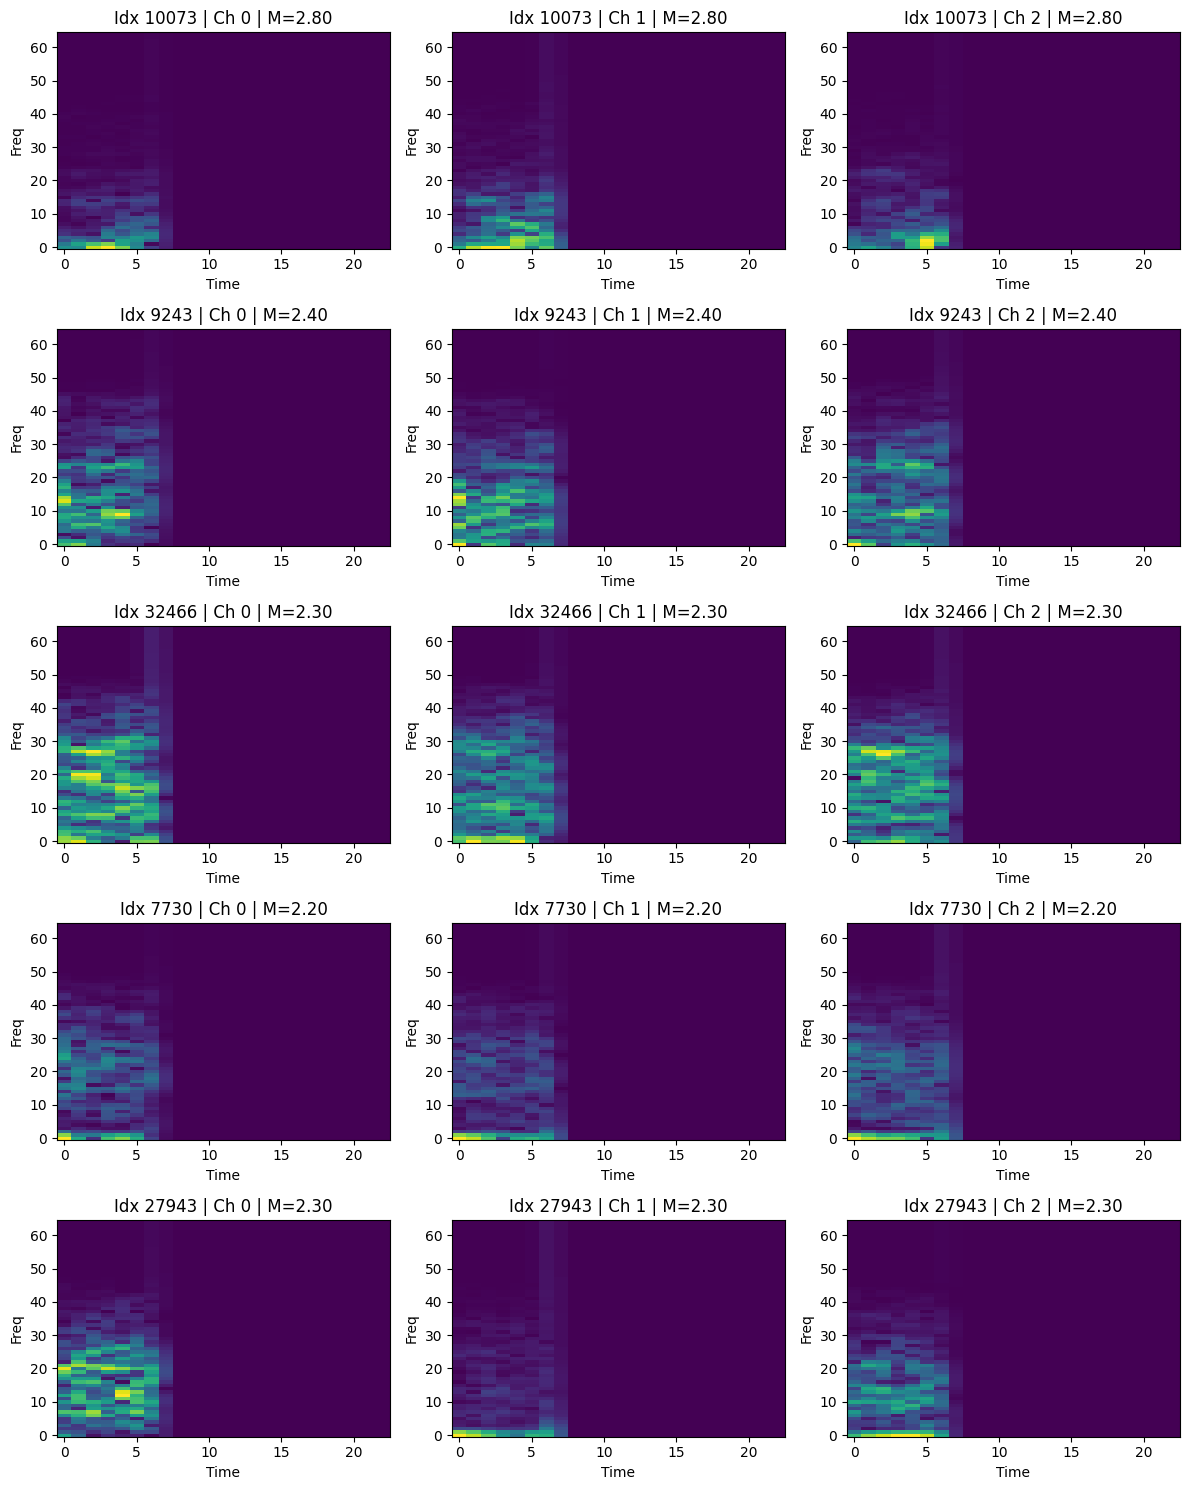

In [ ]:
import torch
import matplotlib.pyplot as plt
import numpy as np
import random
import os
import json

import sys
sys.path.append('../src')
from dataset_definition import UnifiedSeismicDataset
from model_definition import SeismicMagnitudePredictor
import torchaudio.transforms as T

DATA_DIR: str = '/home/aidar/study/senior_thesis/data/INSTANCE/peak_normalized'
waveforms_events_file: str = 'waveforms_events.bin'

info_file: str = 'info.json' 
waveforms_events_file: str = 'waveforms_events.bin'
metadata_events_file: str = 'metadata_events.csv'

with open(os.path.join(DATA_DIR, info_file)) as f:
    info = json.load(f)

n_samples = info['events']['n_written']

memmap_path: str = os.path.join(DATA_DIR, waveforms_events_file)
csv_path: str = os.path.join(DATA_DIR, metadata_events_file)
# --- reuse your dataset ---
dataset = UnifiedSeismicDataset(
    memmap_path=memmap_path,
    csv_path=csv_path,
    n_samples=n_samples,
    target_length=1000,   # or 500 / 800 / 1000
    phase='train'
)

# --- SAME STFT as in model ---
spectrogram = torch.nn.Sequential(
    T.Spectrogram(
        n_fft=128,
        win_length=128,
        hop_length=38,
        window_fn=torch.hann_window,
        power=1.0,
        center=False,
        normalized=False
    )
)

def plot_spectrograms(dataset, n_examples=1):
    indices = random.sample(range(len(dataset)), n_examples)

    fig, axes = plt.subplots(n_examples, 3, figsize=(12, 3 * n_examples))

    if n_examples == 1:
        axes = np.expand_dims(axes, 0)

    for row, idx in enumerate(indices):
        wave, magnitude = dataset[idx]  # (3, 1000)

        # compute spectrogram
        spec = spectrogram(wave)        # (3, freq, time)
        spec = torch.log1p(spec)

        for ch in range(3):
            ax = axes[row, ch]
            im = ax.imshow(
                spec[ch].numpy(),
                aspect='auto',
                origin='lower'
            )
            ax.set_title(f'Idx {idx} | Ch {ch} | M={magnitude.item():.2f}')
            ax.set_xlabel('Time')
            ax.set_ylabel('Freq')

    plt.tight_layout()
    plt.show()


plot_spectrograms(dataset, n_examples=5)